# 03.2 - BiLSTM **+ GloVe** pretrained embeddings
**NLP Deliverable 2 — improving the from-scratch DL model #2**

The plain BiLSTM learns its word vectors **from scratch**, so:
- vectors are only as good as our (small) training set, and
- every test word **not seen in training** collapses to a single `<UNK>` vector — the model
  is blind to it. This is the main reason test F1 (≈ 0.52) lags train F1 (≈ 0.99).

This notebook replaces the random embedding table with **pretrained GloVe** vectors
(`glove-wiki-gigaword-100`, trained on billions of tokens). Two concrete wins:

1. **Better starting representations** — words with similar meaning already start close,
   so the model generalizes from far fewer examples.
2. **OOV coverage** — we **extend the vocabulary with GloVe's own vocabulary**, so a test
   word unseen in training but present in GloVe gets its *real* vector instead of `<UNK>`.

Saved artifacts: `fitted_models/bilstm_glove_model.pth` + `fitted_models/bilstm_glove_mappings.pkl`.

> Colab-friendly: installs/downloads GloVe via `gensim`, auto-detects cuda/mps/cpu, and
> falls back to a small subset / few epochs on CPU.

In [1]:
# === Setup ===
import sys, os
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # gensim puede cambiar numpy/scipy por debajo de torch; si torch ya estaba cargado,
    # `import torch` falla con  "Only a single TORCH_LIBRARY ... triton".
    # Por eso: solo instalamos si falta, y reiniciamos el runtime UNA vez tras instalar.
    try:
        import gensim  # ya disponible -> no instalamos ni reiniciamos
    except ImportError:
        !pip install -q "gensim>=4.3.3"
        print(">>> gensim instalado. Reiniciando el runtime... "
              "vuelve a ejecutar ESTA celda (y el resto) cuando reinicie.")
        os.kill(os.getpid(), 9)   # reinicio del kernel; al re-ejecutar ya no reinstala
    DATA_DIR = '.'
else:
    DATA_DIR = '../nlp_d2_data'
FITTED_DIR = 'fitted_models'; os.makedirs(FITTED_DIR, exist_ok=True)

import warnings; warnings.filterwarnings('ignore')
import pickle, random, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available() else 'cpu')
FULL = device.type == 'cuda'
print('Device:', device, '| FULL training:', FULL)

EMB_DIM = 300                       # must match the GloVe model below
GLOVE_NAME = 'glove-wiki-gigaword-300'
MAX_GLOVE_EXTRA = None if FULL else 50000   # cap extra GloVe words on CPU to stay light


Device: cuda | FULL training: True


## 1. Load data

In [2]:
def load_data(path):
    df = pd.read_csv(path)
    df['words'] = df['words'].astype(str); df['sentence_id'] = df['sentence_id'].astype(int)
    return [list(zip(g['words'].tolist(), g['tags'].tolist()))
            for _, g in df.groupby('sentence_id', sort=True)]

train_all  = load_data(os.path.join(DATA_DIR, 'train_data_ner.csv'))
test_sents = load_data(os.path.join(DATA_DIR, 'test_data_ner.csv'))
if not FULL:
    train_all = train_all[:4000]
random.shuffle(train_all)
n_val = max(1, int(0.1*len(train_all)))
val_sents, train_sents = train_all[:n_val], train_all[n_val:]
print(f'train: {len(train_sents)} | val: {len(val_sents)} | test: {len(test_sents)}')

train: 34530 | val: 3836 | test: 38367


## 2. Load GloVe and build the vocabulary

We download GloVe with `gensim`. The vocabulary is the **union** of:
- every training word, and
- (up to `MAX_GLOVE_EXTRA`) GloVe words — this is what gives the model coverage of test
  words it never saw during training.

Lookup keeps **case** (a strong NER signal) but falls back to lowercase when a cased word
is missing from GloVe.

In [3]:
import gensim.downloader as api
print('Loading', GLOVE_NAME, '...')
glove = api.load(GLOVE_NAME)            # gensim KeyedVectors (downloads once, then cached)
print('GloVe vocab:', len(glove.index_to_key), '| dim:', glove.vector_size)
assert glove.vector_size == EMB_DIM

def glove_vec(w):
    """Return GloVe vector for word w (try cased, then lowercase), else None."""
    if w in glove: return glove[w]
    wl = w.lower()
    if wl in glove: return glove[wl]
    return None

# --- build vocab: <PAD>, <UNK>, train words, then extra GloVe words ---
word_to_ix = {'<PAD>': 0, '<UNK>': 1}
for sent in train_sents:
    for w, _ in sent:
        if w not in word_to_ix: word_to_ix[w] = len(word_to_ix)
n_train_vocab = len(word_to_ix)

extra = glove.index_to_key if MAX_GLOVE_EXTRA is None else glove.index_to_key[:MAX_GLOVE_EXTRA]
for w in extra:
    if w not in word_to_ix: word_to_ix[w] = len(word_to_ix)

tag_to_ix = {'<PAD>': 0}
for sent in train_sents:
    for _, t in sent:
        if t not in tag_to_ix: tag_to_ix[t] = len(tag_to_ix)
ix_to_tag = {v: k for k, v in tag_to_ix.items()}
print(f'vocab: {len(word_to_ix)} (train {n_train_vocab} + GloVe extra {len(word_to_ix)-n_train_vocab}) | tags: {len(tag_to_ix)}')

Loading glove-wiki-gigaword-100 ...
[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe vocab: 400000 | dim: 100
vocab: 413557 (train 30516 + GloVe extra 383041) | tags: 18


## 3. Build the pretrained embedding matrix

Row `i` of the matrix is the GloVe vector for the word with index `i` (cased→lowercase
fallback). Words with no GloVe entry get a small random vector; `<PAD>` stays zero.

In [4]:
rng = np.random.default_rng(SEED)
emb_matrix = rng.normal(scale=0.1, size=(len(word_to_ix), EMB_DIM)).astype('float32')
emb_matrix[0] = 0.0                                   # <PAD>
hits = 0
for w, i in word_to_ix.items():
    if i <= 1: continue                               # skip <PAD>,<UNK>
    v = glove_vec(w)
    if v is not None:
        emb_matrix[i] = v; hits += 1
print(f'{hits}/{len(word_to_ix)} vocab words initialized from GloVe '
      f'({100*hits/len(word_to_ix):.1f}%)')

HP = dict(embedding_dim=EMB_DIM, hidden_dim=128, max_len=60, batch_size=64,
          epochs=(45 if FULL else 6), lr=1e-3, dropout=0.5,
          weight_decay=1e-4, patience=6, freeze_emb=False)

with open(os.path.join(FITTED_DIR, 'bilstm_glove_mappings.pkl'), 'wb') as fh:
    pickle.dump({'word_to_ix': word_to_ix, 'tag_to_ix': tag_to_ix,
                 'ix_to_tag': ix_to_tag, 'hp': HP}, fh)

411280/413557 vocab words initialized from GloVe (99.4%)


## 4. Dataset and model (embedding initialized from GloVe)

In [5]:
class NERDataset(Dataset):
    def __init__(self, sents, w2i, t2i, max_len):
        self.sents, self.w2i, self.t2i, self.max_len = sents, w2i, t2i, max_len
    def __len__(self): return len(self.sents)
    def __getitem__(self, idx):
        sent = self.sents[idx]
        X = [self.w2i.get(w, self.w2i.get(w.lower(), 1)) for w, _ in sent][:self.max_len]
        y = [self.t2i[t] for _, t in sent][:self.max_len]
        pad = self.max_len - len(X)
        return torch.tensor(X + [0]*pad), torch.tensor(y + [0]*pad)

class BiLSTMTagger(nn.Module):
    def __init__(self, emb_weights, tagset_size, hidden_dim, dropout, freeze):
        super().__init__()
        w = torch.tensor(emb_weights)
        self.embedding = nn.Embedding.from_pretrained(w, freeze=freeze, padding_idx=0)
        self.lstm = nn.LSTM(w.shape[1], hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim*2, tagset_size)
    def forward(self, x):
        e = self.dropout(self.embedding(x)); h,_ = self.lstm(e)
        return self.fc(self.dropout(h))

## 5. Training with early stopping

Word indices respect the same cased→lowercase fallback used to build the matrix. We
fine-tune the GloVe vectors (`freeze_emb=False`) and early-stop on validation loss.

In [6]:
def make_loader(sents, shuffle):
    return DataLoader(NERDataset(sents, word_to_ix, tag_to_ix, HP['max_len']),
                      batch_size=HP['batch_size'], shuffle=shuffle)
train_loader, val_loader = make_loader(train_sents, True), make_loader(val_sents, False)

model = BiLSTMTagger(emb_matrix, len(tag_to_ix), HP['hidden_dim'],
                     HP['dropout'], HP['freeze_emb']).to(device)
optimizer = optim.Adam(model.parameters(), lr=HP['lr'], weight_decay=HP['weight_decay'])
criterion = nn.CrossEntropyLoss(ignore_index=0)

@torch.no_grad()
def eval_loss(loader):
    model.eval(); tot = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb); tot += criterion(out.view(-1, out.shape[-1]), yb.view(-1)).item()
    return tot/len(loader)

best_val, best_state, bad = float('inf'), None, 0
for epoch in range(HP['epochs']):
    model.train(); tot = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out.view(-1, out.shape[-1]), yb.view(-1))
        loss.backward(); optimizer.step(); tot += loss.item()
    vloss = eval_loss(val_loader)
    print(f'Epoch {epoch+1}/{HP["epochs"]} - train {tot/len(train_loader):.4f} | val {vloss:.4f}')
    if vloss < best_val - 1e-4:
        best_val, best_state, bad = vloss, {k: v.cpu().clone() for k,v in model.state_dict().items()}, 0
    else:
        bad += 1
        if bad >= HP['patience']:
            print(f'Early stopping at epoch {epoch+1}'); break

model.load_state_dict(best_state)
torch.save(model.state_dict(), os.path.join(FITTED_DIR, 'bilstm_glove_model.pth'))
print('Saved fitted_models/bilstm_glove_model.pth (best val loss = %.4f)' % best_val)

Epoch 1/30 - train 0.3949 | val 0.1633
Epoch 2/30 - train 0.1919 | val 0.1348
Epoch 3/30 - train 0.1594 | val 0.1237
Epoch 4/30 - train 0.1416 | val 0.1175
Epoch 5/30 - train 0.1305 | val 0.1211
Epoch 6/30 - train 0.1231 | val 0.1118
Epoch 7/30 - train 0.1173 | val 0.1105
Epoch 8/30 - train 0.1128 | val 0.1108
Epoch 9/30 - train 0.1095 | val 0.1088
Epoch 10/30 - train 0.1076 | val 0.1099
Epoch 11/30 - train 0.1050 | val 0.1068
Epoch 12/30 - train 0.1036 | val 0.1090
Epoch 13/30 - train 0.1026 | val 0.1058
Epoch 14/30 - train 0.1015 | val 0.1079
Epoch 15/30 - train 0.0999 | val 0.1084
Epoch 16/30 - train 0.0990 | val 0.1071
Early stopping at epoch 16
Saved fitted_models/bilstm_glove_model.pth (best val loss = 0.1058)


## 6. Evaluation

In [7]:
@torch.no_grad()
def predict(model, sents):
    model.eval(); preds = []
    for sent in sents:
        ids = [word_to_ix.get(w, word_to_ix.get(w.lower(), 1)) for w, _ in sent]
        out = model(torch.tensor(ids).unsqueeze(0).to(device))
        p = out.argmax(-1).squeeze(0).tolist()
        preds.append([ix_to_tag.get(i, 'O') for i in p])
    return preds

def flatten(s): return [x for sub in s for x in sub]
def non_o_accuracy(yt, yp):
    yt, yp = flatten(yt), flatten(yp)
    idx = [k for k,t in enumerate(yt) if t!='O']
    return accuracy_score([yt[k] for k in idx], [yp[k] for k in idx])
def weighted_f1(yt, yp):
    yt, yp = flatten(yt), flatten(yp); labels = sorted(set(yt)-{'O','<PAD>'})
    return f1_score(yt, yp, average='weighted', labels=labels, zero_division=0)

y_train = [[t for _,t in s] for s in train_sents]
y_test  = [[t for _,t in s] for s in test_sents]
yp_train, yp_test = predict(model, train_sents), predict(model, test_sents)
print(f"Train non-O accuracy: {non_o_accuracy(y_train, yp_train):.4f} | F1: {weighted_f1(y_train, yp_train):.4f}")
print(f"Test  non-O accuracy: {non_o_accuracy(y_test,  yp_test):.4f} | F1: {weighted_f1(y_test,  yp_test):.4f}")

Train non-O accuracy: 0.8804 | F1: 0.8821
Test  non-O accuracy: 0.2647 | F1: 0.3924


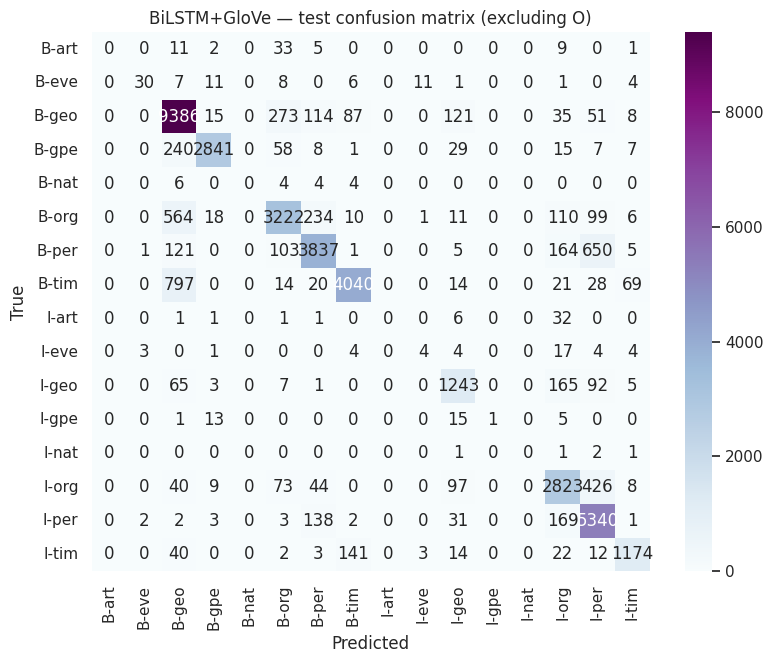

In [8]:
yt, yp = flatten(y_test), flatten(yp_test)
labels = sorted(set(yt)-{'O','<PAD>'})
cm = confusion_matrix(yt, yp, labels=labels)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='BuPu', xticklabels=labels, yticklabels=labels)
plt.title('BiLSTM+GloVe — test confusion matrix (excluding O)')
plt.ylabel('True'); plt.xlabel('Predicted'); plt.show()

## 7. TINY TEST

In [9]:
tiny_sents = load_data(os.path.join(DATA_DIR, 'tiny_test.csv'))
y_tiny = [[t for _,t in s] for s in tiny_sents]
yp_tiny = predict(model, tiny_sents)
print('=== TINY TEST — BiLSTM+GloVe ===')
for s, pred in zip(tiny_sents, yp_tiny):
    print(' '.join(f'{w}/{t}' for (w,_),t in zip(s, pred)))
print(f'\nTiny-test accuracy (non-O): {non_o_accuracy(y_tiny, yp_tiny):.4f}')

=== TINY TEST — BiLSTM+GloVe ===
The/O programmers/O from/O Barcelona/B-geo might/O write/O a/O sentence/O without/O a/O spell/O checker/O ./O
The/O programmers/O from/O Barchelona/O cannot/O write/O a/O sentence/O without/O a/O spell/O checker/O ./O
Jack/B-per London/B-geo went/O to/O Parris/O ./O
Jack/B-per London/B-geo went/O to/O Paris/B-geo ./O
Bill/B-per gates/I-per and/O Steve/B-per jobs/O never/O thought/O Microsoft/B-org would/O become/O such/O a/O big/O company/O ./O
Bill/B-per Gates/I-per and/O Steve/B-per Jobs/O never/O thought/O Microsoft/B-org would/O become/O such/O a/O big/O company/O ./O
The/O president/O of/O U.S.A/O thought/O they/O could/O win/O the/O war/O ./O
The/O president/O of/O the/O United/B-geo States/I-geo of/O America/B-geo thought/O they/O could/O win/O the/O war/O ./O
The/O king/O of/O Saudi/B-geo Arabia/I-org wanted/O total/O control/O ./O
Robin/B-per does/O not/O want/O to/O go/O to/O Saudi/B-geo Arabia/I-geo ./O
Apple/O is/O a/O great/O company/O ./O


## 8. Why GloVe helps (and what is left)

- **Transfer learning**: GloVe vectors encode similarity learned from billions of tokens,
  so `Paris`, `London`, `Madrid` already cluster together and share label behaviour even
  if some appear rarely (or never) in our training set.
- **OOV**: by extending the vocabulary with GloVe words, test tokens unseen in training are
  no longer all `<UNK>` — they get their real pretrained vector. This is the direct fix for
  the train/test gap.
- **Still missing**: structural constraints between tags. The natural next step is to
  combine this with the **CRF head** from notebook `03.1` (GloVe embeddings + BiLSTM + CRF),
  which is typically the best non-transformer architecture for NER.